# Notebook 04b - Spain 2022 Tactical Analysis (Groups E-F + Players)
### Pressing, Transitions & Player Heatmaps (With France Baseline)

In [1]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs/figures/2022', exist_ok=True)
sys.path.insert(0, os.path.abspath('..'))
from utils.config import OUTPUTS_DATA_DIR

df = pd.read_parquet(os.path.join(OUTPUTS_DATA_DIR, 'master_events_cleaned.parquet'))
spain_22 = df[(df['tournament']=='WC2022') & (df['team']=='Spain')].copy()
france_22 = df[(df['tournament']=='WC2022') & (df['team']=='France')].copy()
print(f'Loaded {len(spain_22):,} Spain events')
print(f'Loaded {len(france_22):,} France events')

Loaded 12,322 Spain events
Loaded 13,361 France events


---
## GROUP E: Pressing & Defensive Structure
**Question:** Was Spain's pressing an attacking weapon or purely defensive?

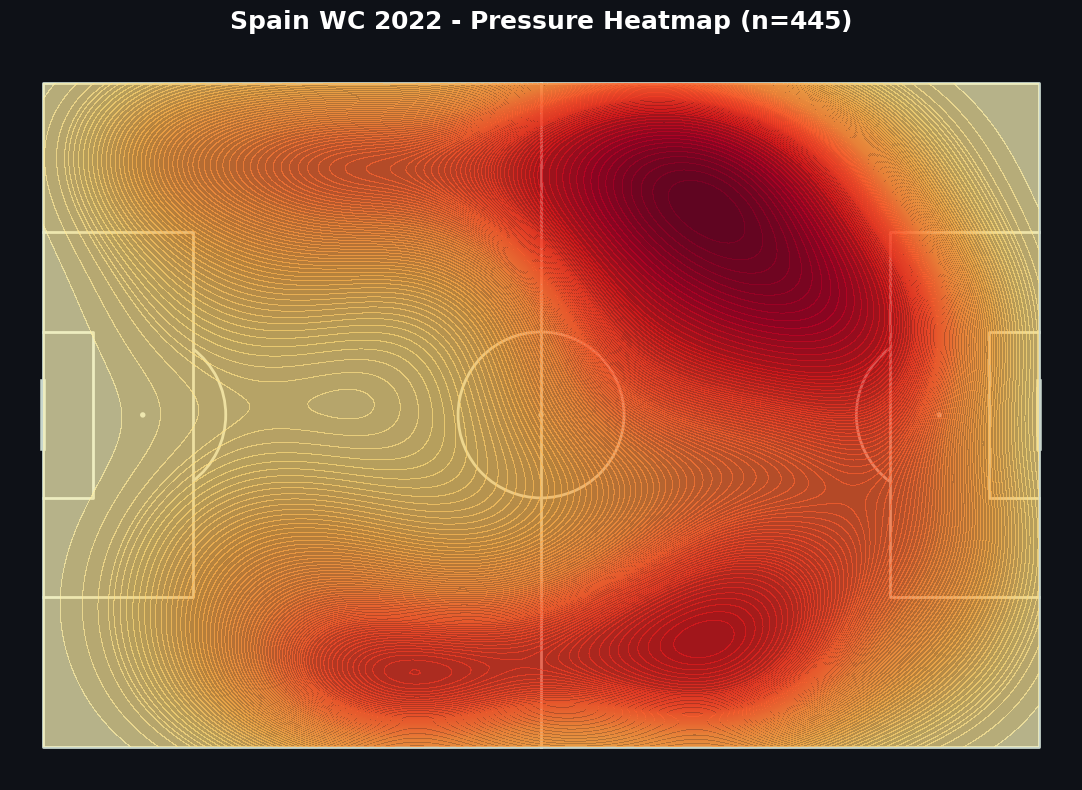

In [2]:
# === VIZ 10: Pressure Heatmap ===
pressures = spain_22[spain_22['type']=='Pressure'].dropna(subset=['x','y'])

pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12,8))
fig.set_facecolor('#0e1117')

pitch.kdeplot(pressures['x'], pressures['y'], ax=ax, fill=True, levels=100,
              thresh=0, cut=4, cmap='YlOrRd', alpha=0.7, zorder=1)

ax.set_title(f'Spain WC 2022 - Pressure Heatmap (n={len(pressures)})', color='white', fontsize=18, fontweight='bold', pad=15)
plt.savefig('../outputs/figures/2022/viz10_pressure_heatmap.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Average Pressure Height: {pressures['x'].mean():.1f} yards from own goal")

In [3]:
# === Pressing Stats: PPDA and High Recoveries ===
print('SPAIN WC2022 - PRESSING METRICS (Group E)')
print('='*55)

# High recoveries (ball recoveries in final/middle third)
recoveries = spain_22[spain_22['type']=='Ball Recovery'].dropna(subset=['x'])
high_rec = recoveries[recoveries['x'] >= 60]  # middle+final third
print(f'  Total ball recoveries   : {len(recoveries)}')
print(f'  High recoveries (x>=60) : {len(high_rec)} ({len(high_rec)/len(recoveries):.0%})')

# Pressure success
if 'pressure_outcome' in spain_22.columns:
    p_total = len(pressures)
    # No outcome = successful pressure in StatsBomb
    p_success = pressures['pressure_outcome'].isna().sum() if 'pressure_outcome' in pressures.columns else 0
    print(f'  Pressures               : {p_total}')
    
print(f'\n  Pressing by zone:')
for z in ['Defensive Third','Middle Third','Final Third']:
    n = (pressures['zone_third']==z).sum()
    print(f'    {z:20s}: {n:3d} ({n/len(pressures):.0%})')

SPAIN WC2022 - PRESSING METRICS (Group E)
  Total ball recoveries   : 189
  High recoveries (x>=60) : 88 (47%)

  Pressing by zone:
    Defensive Third     : 107 (24%)
    Middle Third        : 170 (38%)
    Final Third         : 168 (38%)


---
## GROUP F: Transition Attack
**Question:** How dangerous was Spain immediately after winning the ball?

In [4]:
# === Transition Analysis ===
# After a Ball Recovery or Interception, how quickly did Spain create danger?
regains = spain_22[spain_22['type'].isin(['Ball Recovery','Interception'])].copy()

print('SPAIN WC2022 - TRANSITION METRICS (H5 Test)')
print('='*55)
print(f'  Total regains (Recovery + Interception): {len(regains)}')

# High regains (final third + middle third, x >= 60)
high_regains = regains[regains['x'] >= 60]
print(f'  High regains (x >= 60)                : {len(high_regains)}')

# Check if any shots happened within 10 seconds of a high regain
# We approximate by checking if a shot by Spain happened in the same match within 10 seconds
shots_after = 0
for _, reg in high_regains.iterrows():
    match_shots = spain_22[(spain_22['match_id']==reg['match_id']) & 
                           (spain_22['type']=='Shot') &
                           (spain_22['minute']>=reg['minute']) &
                           (spain_22['minute']<=reg['minute']+1)]  # within ~1 min
    if len(match_shots)>0:
        shots_after += 1

print(f'  High regains leading to shot (1 min)  : {shots_after}')
print(f'  Transition threat rate                : {shots_after/max(1,len(high_regains)):.1%}')

SPAIN WC2022 - TRANSITION METRICS (H5 Test)
  Total regains (Recovery + Interception): 226
  High regains (x >= 60)                : 97


  High regains leading to shot (1 min)  : 42


  Transition threat rate                : 43.3%


---
## PLAYER HEATMAPS (Group H)
**Question:** What role did each key player actually occupy on the pitch?

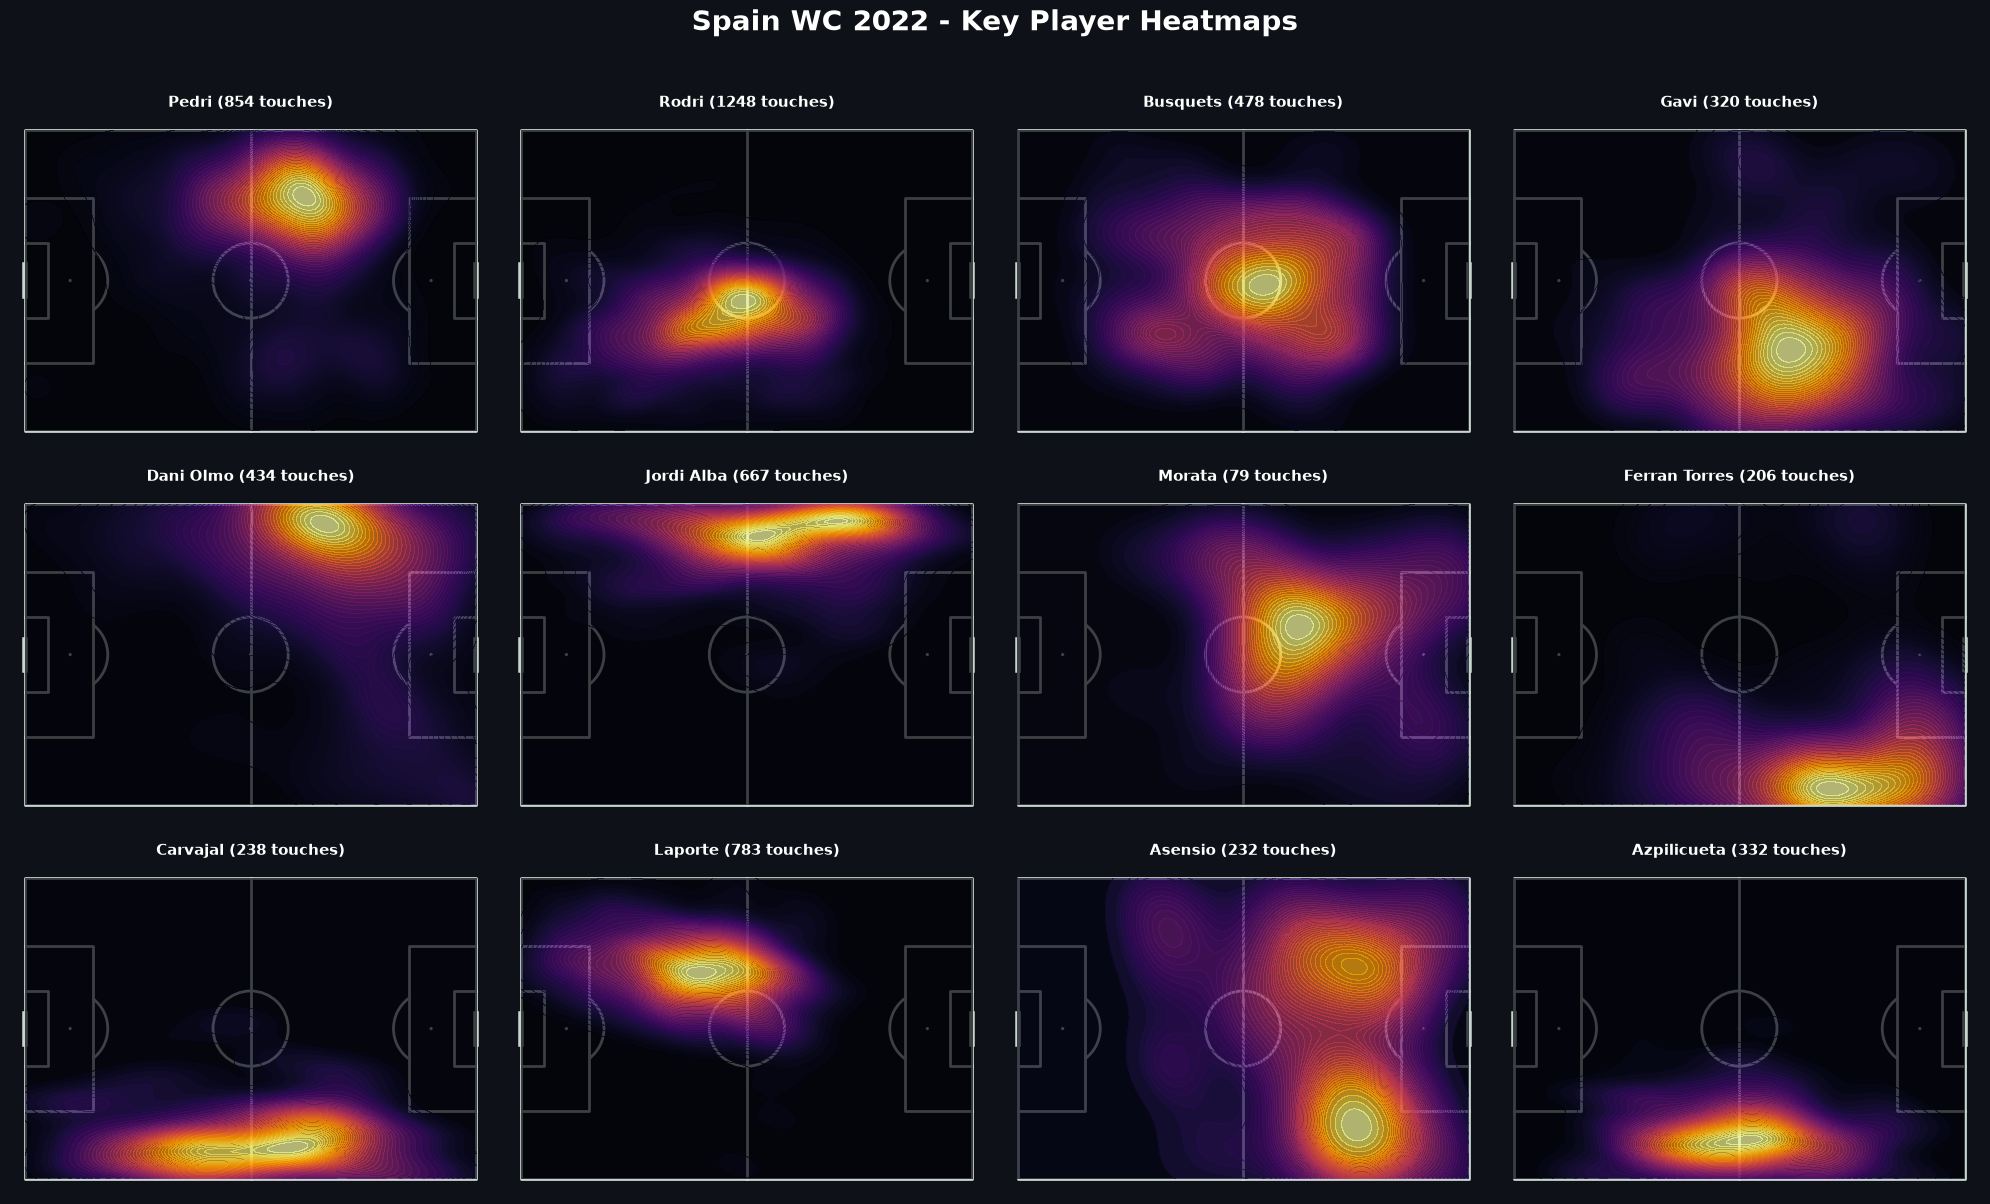

In [5]:
# === VIZ 15: Player Heatmap Panels (SPAIN) ===
key_players = ['Pedri','Rodri','Busquets','Gavi','Dani Olmo','Jordi Alba','Morata','Ferran Torres', 'Daniel Carvajal Ramos', 'Laporte', 'Marco Asensio Willemsen', 'César Azpilicueta Tanco']

# Filter to players who actually have events
available = [p for p in key_players if p in spain_22['common_name'].values or p in spain_22['player'].values]

n_players = len(available)
cols = 4
rows = (n_players + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), facecolor='#0e1117')
if rows == 1:
    axes = [axes]

for idx, player in enumerate(available):
    row_idx, col_idx = idx // cols, idx % cols
    ax = axes[row_idx][col_idx] if rows > 1 else axes[col_idx]
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
    pitch.draw(ax=ax)
    
    p_events = spain_22[((spain_22['common_name']==player) | (spain_22['player']==player)) & 
                        spain_22['type'].isin(['Pass','Carry','Ball Recovery','Dribble'])]
    p_events = p_events.dropna(subset=['x','y'])
    
    if len(p_events) > 5:
        pitch.kdeplot(p_events['x'], p_events['y'], ax=ax, fill=True, levels=50,
                      thresh=0, cut=4, cmap='inferno', alpha=0.7)
    
    # Clean up name for display
    clean_name = player.split(' ')[-1] if len(player.split(' ')) > 2 else player
    if 'Carvajal' in player: clean_name = 'Carvajal'
    elif 'Azpilicueta' in player: clean_name = 'Azpilicueta'
    elif 'Asensio' in player: clean_name = 'Asensio'
        
    ax.set_title(f'{clean_name} ({len(p_events)} touches)', color='white', fontsize=11, fontweight='bold')

# Hide empty axes
for idx in range(len(available), rows*cols):
    row_idx, col_idx = idx // cols, idx % cols
    ax = axes[row_idx][col_idx] if rows > 1 else axes[col_idx]
    ax.set_visible(False)

fig.suptitle('Spain WC 2022 - Key Player Heatmaps', color='white', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/2022/viz15_player_heatmaps_spain.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

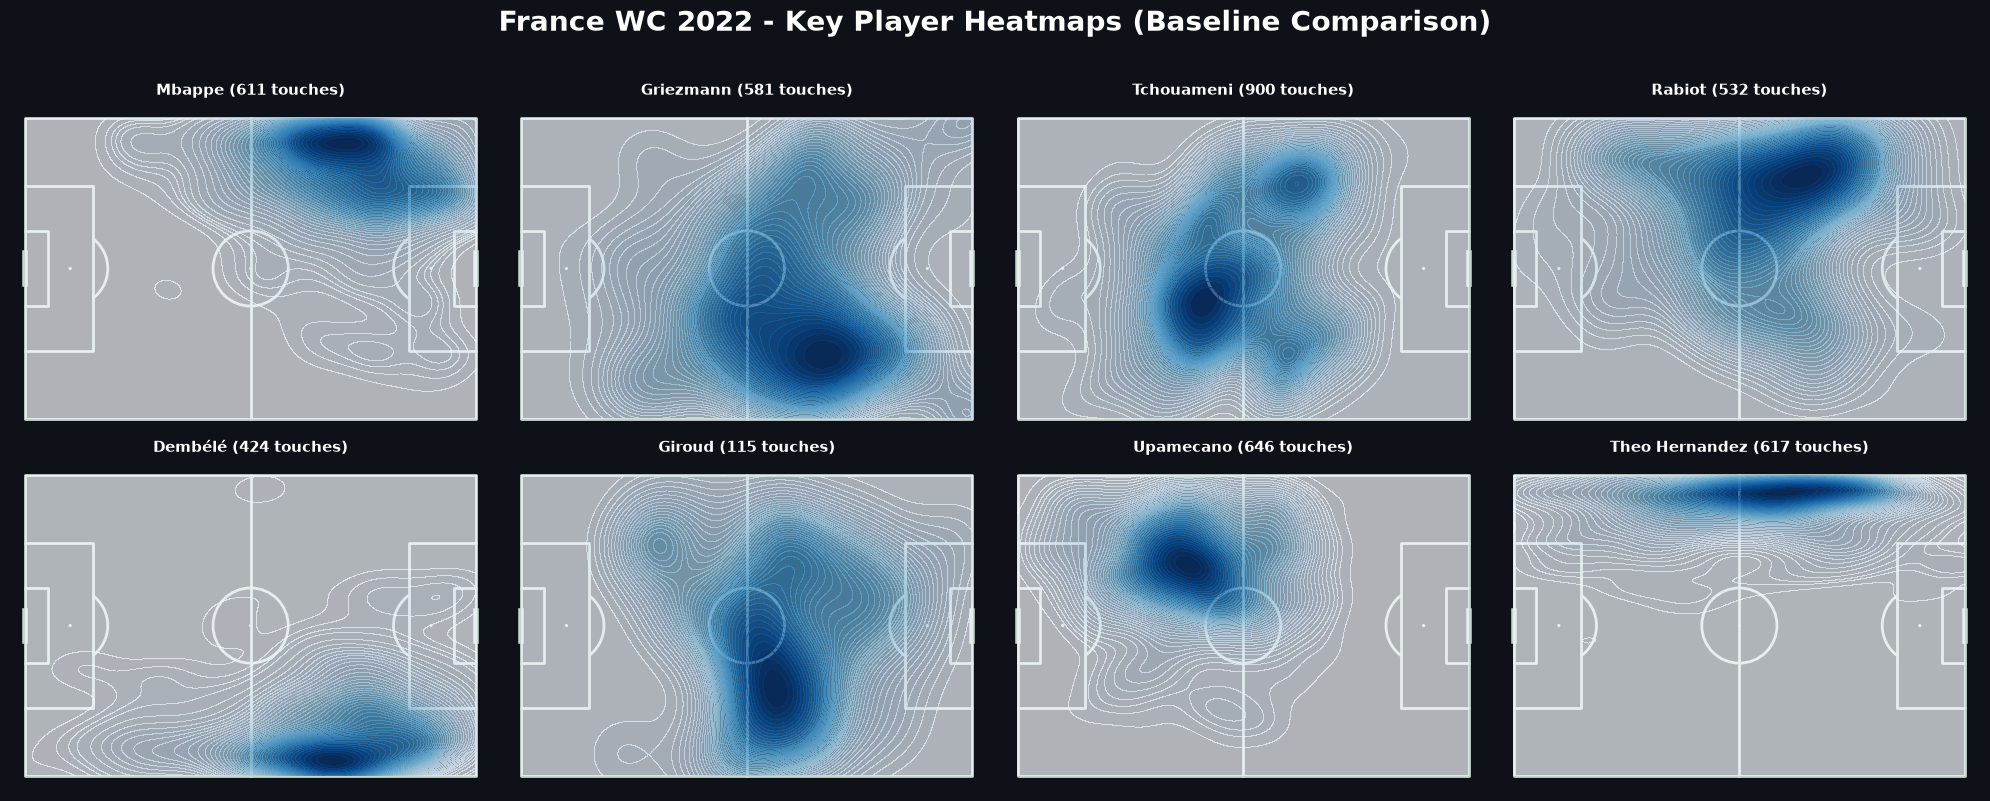

In [6]:
# === VIZ 16: Player Heatmap Panels (FRANCE BASELINE) ===
# Find exact names in the dataset using partial matching to avoid encoding issues
search_names = ['Mbapp', 'Griezmann', 'Tchouam', 'Rabiot', 'Demb', 'Giroud', 'Upamecano', 'Hern']

france_players = []
for sn in search_names:
    matches = france_22[france_22['player'].str.contains(sn, na=False)]['player'].unique()
    if len(matches) > 0:
        france_players.append(matches[0])

n_players = len(france_players)
cols = 4
rows = (n_players + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), facecolor='#0e1117')
if rows == 1:
    axes = [axes]

for idx, player in enumerate(france_players):
    row_idx, col_idx = idx // cols, idx % cols
    ax = axes[row_idx][col_idx] if rows > 1 else axes[col_idx]
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
    pitch.draw(ax=ax)
    
    p_events = france_22[(france_22['player']==player) & 
                         france_22['type'].isin(['Pass','Carry','Ball Recovery','Dribble'])]
    p_events = p_events.dropna(subset=['x','y'])
    
    if len(p_events) > 5:
        pitch.kdeplot(p_events['x'], p_events['y'], ax=ax, fill=True, levels=50,
                      thresh=0, cut=4, cmap='Blues', alpha=0.7)
    
    # Clean up name for display
    clean_name = player.split(' ')[-1] if len(player.split(' ')) > 1 else player
    if 'Mbapp' in clean_name or 'Mbapp' in player:
        clean_name = 'Mbappe'
    elif 'Griezmann' in player:
        clean_name = 'Griezmann'
    elif 'Tchouam' in player:
        clean_name = 'Tchouameni'
    elif 'Hern' in player:
        clean_name = 'Theo Hernandez'
        
    ax.set_title(f'{clean_name} ({len(p_events)} touches)', color='white', fontsize=11, fontweight='bold')

for idx in range(len(france_players), rows*cols):
    row_idx, col_idx = idx // cols, idx % cols
    ax = axes[row_idx][col_idx] if rows > 1 else axes[col_idx]
    ax.set_visible(False)

fig.suptitle('France WC 2022 - Key Player Heatmaps (Baseline Comparison)', color='white', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/2022/viz16_player_heatmaps_france.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Notebook 04 - Key Findings Summary

The data from Groups A-F paints a clear picture of Spain's 2022 tactical profile:

1. **Territory was deep, not dangerous** - Touch distribution skewed heavily toward defensive and middle thirds
2. **Pass networks confirm U-shape** - Heavy links between CBs, Busquets, and fullbacks; weak links into forward line
3. **Progressive actions were limited** - Few line-breaking passes or carries into the penalty area
4. **Final-third entries favored wide zones** - Central penetration was rare
5. **xG was modest** - Shot quality was low, suggesting creation problems not just finishing
6. **Pressing was high-volume but rarely led to shots** - Transition threat was minimal

**Next:** Notebook 05 (Morocco Case Study) and Notebook 07 (Euro 2024 Evolution)